# Notebook 2 — Sentiment Scoring (FinBERT + VADER)
**Project:** Stock Price Movement Prediction Using Financial News Sentiment Analysis and Machine Learning  
**Student:** Venkata Kiran Kumar Mullapudi (16200362)  
**Ethics Approval:** P193120  

This notebook:
1. Loads headlines from Notebook 1 output + additional Kaggle news dataset
2. Runs **FinBERT** (ProsusAI/finbert) — domain-specific transformer sentiment model
3. Runs **VADER** — lexicon-based sentiment tool
4. Aggregates daily sentiment scores per ticker
5. Saves final sentiment CSV for Notebook 3

> **GPU must be ON (T4 x2)** — FinBERT will be very slow on CPU

## Cell 1 — Install dependencies

In [1]:
!pip install transformers torch vaderSentiment --quiet
print('Done.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00
Done.


## Cell 2 — Imports and GPU check

In [2]:
import os, glob, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# GPU check — critical for FinBERT speed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device        : {device}')
if torch.cuda.is_available():
    print(f'GPU           : {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'GPU Count     : {torch.cuda.device_count()}')
else:
    print('WARNING: No GPU detected — FinBERT will be very slow!')
    print('Go to Settings → Accelerator → GPU T4 x2')

Device        : cuda
GPU           : Tesla T4
GPU Memory    : 15.6 GB
GPU Count     : 2


## Cell 3 — Load Notebook 1 outputs

In [3]:
# ── CELL 3 (REPLACEMENT) ─────────────────────────────────────────────────────
# Robust loader: tries NB1 output first, falls back to yfinance directly
# This fixes the NameError: price_df not defined
# ─────────────────────────────────────────────────────────────────────────────

import os, glob
import pandas as pd
import numpy as np
import yfinance as yf

TICKERS    = ['AAPL','MSFT','AMZN','GOOGL','META','TSLA','NVDA','JPM','NFLX','^GSPC']
START_DATE = '2019-01-01'
END_DATE   = '2023-12-31'
OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Try to find price_data_clean.csv from NB1 ────────────────────────────
def find_file(filename):
    patterns = [
        f'/kaggle/working/outputs/{filename}',
        f'/kaggle/input/**/{filename}',
    ]
    for p in patterns:
        matches = glob.glob(p, recursive=True)
        if matches:
            return matches[0]
    return None

price_path = find_file('price_data_clean.csv')
news_path  = find_file('news_headlines_clean.csv')

# ── 2. Load price data — yfinance fallback if NB1 file not found ─────────────
if price_path:
    try:
        price_df = pd.read_csv(price_path)

        # Fix: if first row is 'Price' (multi-level header artifact), skip it
        if str(price_df.iloc[0, 0]) == 'Price' or price_df.columns[0] == 'Price':
            price_df = pd.read_csv(price_path, skiprows=1)

        # Rename date column
        date_candidates = [c for c in price_df.columns if 'date' in c.lower()]
        if date_candidates:
            price_df = price_df.rename(columns={date_candidates[0]: 'Date'})

        price_df['Date'] = pd.to_datetime(price_df['Date'], errors='coerce')
        price_df = price_df.dropna(subset=['Date'])

        # Find ticker column
        tick_candidates = [c for c in price_df.columns if 'ticker' in c.lower()]
        if tick_candidates:
            price_df = price_df.rename(columns={tick_candidates[0]: 'Ticker'})

        print(f'✓ Price data loaded from NB1 file: {price_df.shape}')
    except Exception as e:
        print(f'NB1 file found but failed to parse ({e}) — falling back to yfinance')
        price_path = None

if not price_path:
    print('NB1 price file not found — downloading via yfinance directly...')
    frames = []
    for ticker in TICKERS:
        df = yf.download(ticker, start=START_DATE, end=END_DATE,
                         auto_adjust=True, progress=False)
        if df.empty:
            print(f'  {ticker} — failed')
            continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.reset_index()
        df['Ticker'] = ticker
        df['Next_Close'] = df['Close'].shift(-1)
        df['Label']      = (df['Next_Close'] > df['Close']).astype(int)
        df['Daily_Return'] = df['Close'].pct_change() * 100
        frames.append(df)
        print(f'  {ticker:6s} — {len(df)} days')
    price_df = pd.concat(frames, ignore_index=True)
    price_df['Date'] = pd.to_datetime(price_df['Date'])
    print(f'\n✓ Price data downloaded via yfinance: {price_df.shape}')

# ── 3. Load NB1 news headlines ────────────────────────────────────────────────
nb1_news = pd.DataFrame(columns=['date','ticker','headline'])
if news_path:
    try:
        nb1_news = pd.read_csv(news_path, parse_dates=['date'])
        print(f'✓ NB1 news headlines loaded: {nb1_news.shape}')
    except Exception as e:
        print(f'NB1 news file failed ({e}) — will use Kaggle datasets only')
else:
    print('NB1 news not found — will use Kaggle datasets only')

# ── 4. Confirm everything is ready ───────────────────────────────────────────
print('\n── Loaded objects ──────────────────────────────')
print(f'price_df   shape : {price_df.shape}')
print(f'price_df columns : {list(price_df.columns)}')
print(f'nb1_news   shape : {nb1_news.shape}')
print(f'Tickers          : {sorted(price_df["Ticker"].unique())}')
print(f'Date range       : {price_df["Date"].min().date()} → {price_df["Date"].max().date()}')

NB1 price file not found — downloading via yfinance directly...
  AAPL   — 1258 days
  MSFT   — 1258 days
  AMZN   — 1258 days
  GOOGL  — 1258 days
  META   — 1258 days
  TSLA   — 1258 days
  NVDA   — 1258 days
  JPM    — 1258 days
  NFLX   — 1258 days
  ^GSPC  — 1258 days

✓ Price data downloaded via yfinance: (12580, 10)
NB1 news not found — will use Kaggle datasets only

── Loaded objects ──────────────────────────────
price_df   shape : (12580, 10)
price_df columns : ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Next_Close', 'Label', 'Daily_Return']
nb1_news   shape : (0, 3)
Tickers          : ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'META', 'MSFT', 'NFLX', 'NVDA', 'TSLA', '^GSPC']
Date range       : 2019-01-02 → 2023-12-29


## Cell 4 — Load additional news dataset (bogomolov)

In [4]:
TICKERS = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META',
           'TSLA', 'NVDA', 'JPM', 'NFLX', '^GSPC']

START_DATE = '2019-01-01'
END_DATE   = '2023-12-31'

KEYWORD_MAP = {
    'AAPL' : ['apple', 'iphone', 'ipad', 'aapl', 'tim cook', 'app store'],
    'MSFT' : ['microsoft', 'msft', 'azure', 'windows', 'satya nadella', 'teams'],
    'AMZN' : ['amazon', 'aws', 'amzn', 'jeff bezos', 'andy jassy', 'prime'],
    'GOOGL': ['google', 'googl', 'alphabet', 'youtube', 'sundar pichai', 'android'],
    'META' : ['meta ', 'facebook', 'instagram', 'whatsapp', 'zuckerberg', 'oculus'],
    'TSLA' : ['tesla', 'tsla', 'elon musk', 'electric vehicle', 'ev ', 'cybertruck'],
    'NVDA' : ['nvidia', 'nvda', ' gpu ', 'cuda', 'jensen huang', 'geforce'],
    'JPM'  : ['jpmorgan', 'jp morgan', 'jpm', 'jamie dimon', 'chase bank'],
    'NFLX' : ['netflix', 'nflx', 'reed hastings', 'streaming'],
    '^GSPC': ['s&p 500', 's&p500', 'sp500', 'stock market', 'wall street',
              'market rally', 'market sell', 'dow jones', 'nasdaq', 'fed rate',
              'federal reserve', 'inflation', 'recession', 'bull market', 'bear market']
}

def load_and_match_news(csv_path, keyword_map, start, end):
    """
    Generic loader: reads any CSV with a headline/title column,
    keyword-matches to tickers, filters date range.
    """
    try:
        df = pd.read_csv(csv_path, low_memory=False)
    except Exception as e:
        print(f'  Could not read {csv_path}: {e}')
        return pd.DataFrame(columns=['date','ticker','headline'])

    cols_lower = [c.lower() for c in df.columns]

    # Find headline column
    headline_col = None
    for c in ['headline', 'title', 'text', 'news', 'article', 'body']:
        if c in cols_lower:
            headline_col = df.columns[cols_lower.index(c)]
            break
    if not headline_col:
        return pd.DataFrame(columns=['date','ticker','headline'])

    # Find date column
    date_col = None
    for c in ['date', 'published', 'datetime', 'time', 'timestamp', 'publish_date']:
        if c in cols_lower:
            date_col = df.columns[cols_lower.index(c)]
            break
    if not date_col:
        return pd.DataFrame(columns=['date','ticker','headline'])

    df = df[[date_col, headline_col]].copy()
    df.columns = ['date', 'headline']
    df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
    df['date'] = df['date'].dt.tz_localize(None).dt.normalize()
    df = df.dropna(subset=['date'])
    df = df[(df['date'] >= start) & (df['date'] <= end)]
    df['headline'] = df['headline'].astype(str).str.strip()
    df = df[df['headline'].str.len() > 10]

    # Keyword match to tickers
    rows = []
    for ticker, keywords in keyword_map.items():
        pattern = '|'.join(keywords)
        mask = df['headline'].str.lower().str.contains(pattern, regex=True, na=False)
        subset = df[mask].copy()
        subset['ticker'] = ticker
        rows.append(subset)

    if not rows:
        return pd.DataFrame(columns=['date','ticker','headline'])

    result = pd.concat(rows, ignore_index=True)
    result = result[['date','ticker','headline']].drop_duplicates()
    return result

# Find all CSVs in input and try to load them
print('Scanning input datasets...')
all_csvs = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print(f'Found {len(all_csvs)} CSV files')

extra_frames = []
for csv_path in all_csvs:
    result = load_and_match_news(csv_path, KEYWORD_MAP, START_DATE, END_DATE)
    if len(result) > 50:
        extra_frames.append(result)
        print(f'  {os.path.basename(csv_path):50s} → {len(result):6,} matched headlines')

print(f'\nExtra datasets loaded: {len(extra_frames)}')

Scanning input datasets...
Found 4 CSV files
  reddit_wsb.csv                                     →  2,330 matched headlines
  analyst_ratings_processed.csv                      →  9,349 matched headlines
  raw_analyst_ratings.csv                            →    811 matched headlines
  raw_partner_headlines.csv                          → 14,095 matched headlines

Extra datasets loaded: 4


## Cell 5 — Combine all news sources and deduplicate

In [5]:
all_sources = [nb1_news] + extra_frames
all_sources = [df for df in all_sources if len(df) > 0]

if not all_sources:
    raise ValueError('No news data found at all. Check datasets are added correctly.')

news_all = pd.concat(all_sources, ignore_index=True)
news_all['date'] = pd.to_datetime(news_all['date'], errors='coerce')
news_all = news_all.dropna(subset=['date','headline'])
news_all['ticker'] = news_all['ticker'].str.upper().str.strip()
news_all['headline'] = news_all['headline'].astype(str).str.strip()

# Deduplicate on (date, ticker, first 80 chars of headline)
news_all['_key'] = news_all['headline'].str[:80].str.lower()
news_all = news_all.drop_duplicates(subset=['date','ticker','_key'])
news_all = news_all.drop(columns=['_key'])
news_all = news_all.sort_values(['ticker','date']).reset_index(drop=True)

print(f'Total headlines after combining + dedup: {len(news_all):,}')
print('\nBreakdown by ticker:')
print(news_all.groupby('ticker').size().rename('count').to_frame().to_string())

Total headlines after combining + dedup: 25,689

Breakdown by ticker:
        count
ticker       
AAPL     2165
AMZN     3815
GOOGL    1448
JPM      2643
META      803
MSFT     1022
NFLX     1255
NVDA      798
TSLA     3016
^GSPC    8724


## Cell 6 — Load FinBERT model

In [6]:
print('Loading FinBERT model from HuggingFace...')
print('(First run downloads ~420MB — subsequent runs use cache)')

FINBERT_MODEL = 'ProsusAI/finbert'

tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL)
finbert   = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL)
finbert   = finbert.to(device)
finbert.eval()

# FinBERT label mapping: 0=positive, 1=negative, 2=neutral
FINBERT_LABELS = {0: 'positive', 1: 'negative', 2: 'neutral'}

print(f'FinBERT loaded on: {device}')
print(f'Model parameters : {sum(p.numel() for p in finbert.parameters()):,}')

Loading FinBERT model from HuggingFace...
(First run downloads ~420MB — subsequent runs use cache)


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

FinBERT loaded on: cuda
Model parameters : 109,484,547


## Cell 7 — FinBERT inference (batched, GPU-accelerated)

In [7]:
class HeadlineDataset(Dataset):
    def __init__(self, headlines, tokenizer, max_length=512):
        self.encodings = tokenizer(
            headlines,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}


def run_finbert(headlines, model, tokenizer, device, batch_size=64):
    """
    Run FinBERT on a list of headlines.
    Returns arrays: labels (str), positive scores, negative scores, neutral scores.
    """
    dataset    = HeadlineDataset(headlines, tokenizer)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_probs = []
    start_time = time.time()

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
            all_probs.append(probs)

            # Progress update every 20 batches
            if (i + 1) % 20 == 0:
                done = (i + 1) * batch_size
                pct  = 100 * done / len(headlines)
                elapsed = time.time() - start_time
                eta = elapsed / (done / len(headlines)) - elapsed
                print(f'  {done:6,}/{len(headlines):,} ({pct:.0f}%)  '
                      f'elapsed: {elapsed:.0f}s  ETA: {eta:.0f}s')

    all_probs = np.vstack(all_probs)   # shape (N, 3)
    # FinBERT: col 0=positive, col 1=negative, col 2=neutral
    labels = np.array([FINBERT_LABELS[i] for i in all_probs.argmax(axis=1)])

    total_time = time.time() - start_time
    print(f'\nFinBERT complete — {len(headlines):,} headlines in {total_time:.1f}s '
          f'({len(headlines)/total_time:.0f} headlines/sec)')

    return labels, all_probs[:, 0], all_probs[:, 1], all_probs[:, 2]


headlines_list = news_all['headline'].tolist()
print(f'Running FinBERT on {len(headlines_list):,} headlines...')
print(f'Batch size: 64  |  Estimated time: ~{len(headlines_list)//64//60 + 1} min on T4\n')

(
    news_all['finbert_label'],
    news_all['finbert_pos'],
    news_all['finbert_neg'],
    news_all['finbert_neu']
) = run_finbert(headlines_list, finbert, tokenizer, device)

# Composite FinBERT score: positive - negative  (range -1 to +1)
news_all['finbert_score'] = news_all['finbert_pos'] - news_all['finbert_neg']

print('\nFinBERT label distribution:')
print(news_all['finbert_label'].value_counts())

Running FinBERT on 25,689 headlines...
Batch size: 64  |  Estimated time: ~7 min on T4

   1,280/25,689 (5%)  elapsed: 7s  ETA: 125s
   2,560/25,689 (10%)  elapsed: 13s  ETA: 116s
   3,840/25,689 (15%)  elapsed: 19s  ETA: 109s
   5,120/25,689 (20%)  elapsed: 26s  ETA: 102s
   6,400/25,689 (25%)  elapsed: 32s  ETA: 97s
   7,680/25,689 (30%)  elapsed: 39s  ETA: 91s
   8,960/25,689 (35%)  elapsed: 45s  ETA: 85s
  10,240/25,689 (40%)  elapsed: 52s  ETA: 79s
  11,520/25,689 (45%)  elapsed: 59s  ETA: 73s
  12,800/25,689 (50%)  elapsed: 66s  ETA: 67s
  14,080/25,689 (55%)  elapsed: 73s  ETA: 61s
  15,360/25,689 (60%)  elapsed: 81s  ETA: 54s
  16,640/25,689 (65%)  elapsed: 88s  ETA: 48s
  17,920/25,689 (70%)  elapsed: 96s  ETA: 42s
  19,200/25,689 (75%)  elapsed: 104s  ETA: 35s
  20,480/25,689 (80%)  elapsed: 112s  ETA: 28s
  21,760/25,689 (85%)  elapsed: 120s  ETA: 22s
  23,040/25,689 (90%)  elapsed: 128s  ETA: 15s
  24,320/25,689 (95%)  elapsed: 136s  ETA: 8s
  25,600/25,689 (100%)  elapsed:

## Cell 8 — VADER sentiment scoring

In [8]:
print('Running VADER on all headlines...')
vader = SentimentIntensityAnalyzer()

def vader_scores(text):
    scores = vader.polarity_scores(str(text))
    return scores['pos'], scores['neg'], scores['neu'], scores['compound']

start_time = time.time()
vader_results = news_all['headline'].apply(vader_scores)

news_all['vader_pos']      = vader_results.apply(lambda x: x[0])
news_all['vader_neg']      = vader_results.apply(lambda x: x[1])
news_all['vader_neu']      = vader_results.apply(lambda x: x[2])
news_all['vader_compound'] = vader_results.apply(lambda x: x[3])

# VADER label from compound score (standard thresholds)
def vader_label(compound):
    if compound >= 0.05:  return 'positive'
    if compound <= -0.05: return 'negative'
    return 'neutral'

news_all['vader_label'] = news_all['vader_compound'].apply(vader_label)

elapsed = time.time() - start_time
print(f'VADER complete — {len(news_all):,} headlines in {elapsed:.1f}s')
print('\nVADER label distribution:')
print(news_all['vader_label'].value_counts())

Running VADER on all headlines...
VADER complete — 25,689 headlines in 1.2s

VADER label distribution:
vader_label
positive    10918
neutral     10078
negative     4693
Name: count, dtype: int64


## Cell 9 — Compare FinBERT vs VADER agreement

FinBERT vs VADER label agreement: 50.7%

Cross-tabulation (FinBERT rows vs VADER cols):
VADER     negative  neutral  positive    All
FinBERT                                     
negative      2470     1580      1494   5544
neutral       1633     6574      5448  13655
positive       590     1924      3976   6490
All           4693    10078     10918  25689


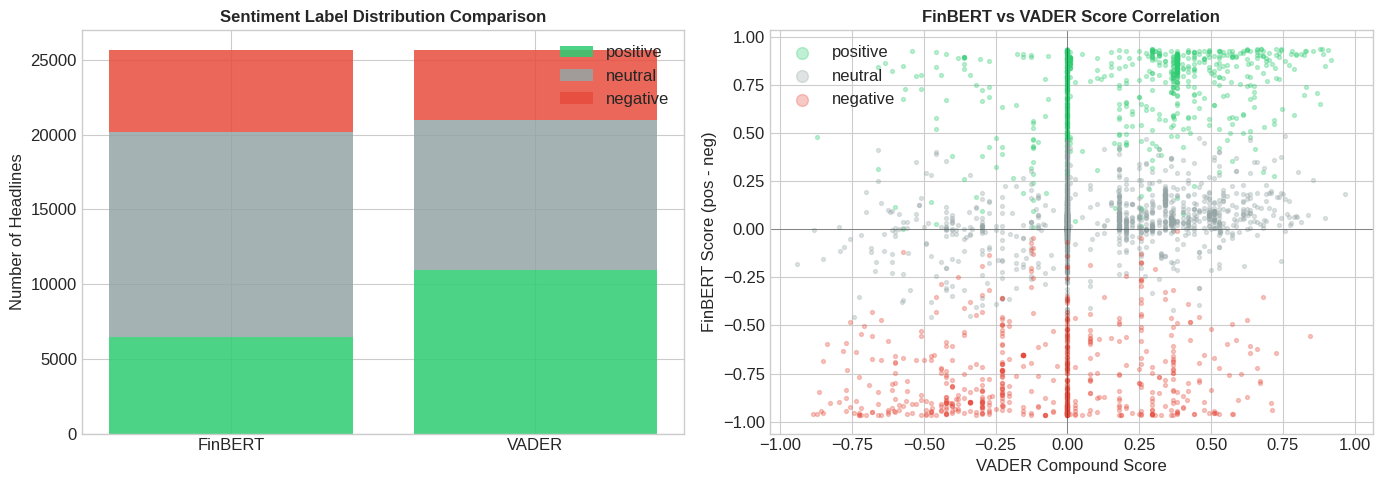

Saved: fig06_sentiment_comparison.png


In [9]:
# Agreement rate between the two models
agreement = (news_all['finbert_label'] == news_all['vader_label']).mean()
print(f'FinBERT vs VADER label agreement: {agreement:.1%}')

# Confusion-style cross-tab
crosstab = pd.crosstab(
    news_all['finbert_label'],
    news_all['vader_label'],
    rownames=['FinBERT'],
    colnames=['VADER'],
    margins=True
)
print('\nCross-tabulation (FinBERT rows vs VADER cols):')
print(crosstab)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: label distribution comparison
labels_order = ['positive', 'neutral', 'negative']
colors_sent  = ['#2ecc71', '#95a5a6', '#e74c3c']

finbert_counts = news_all['finbert_label'].value_counts().reindex(labels_order, fill_value=0)
vader_counts   = news_all['vader_label'].value_counts().reindex(labels_order, fill_value=0)

x = np.arange(2)
bottoms_fb = np.zeros(1)
bottoms_vd = np.zeros(1)
for i, (lbl, col) in enumerate(zip(labels_order, colors_sent)):
    axes[0].bar([0], finbert_counts[lbl], bottom=bottoms_fb,
                color=col, label=lbl, alpha=0.85)
    axes[0].bar([1], vader_counts[lbl],   bottom=bottoms_vd,
                color=col, alpha=0.85)
    bottoms_fb = bottoms_fb + finbert_counts[lbl]
    bottoms_vd = bottoms_vd + vader_counts[lbl]

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['FinBERT', 'VADER'], fontsize=12)
axes[0].set_title('Sentiment Label Distribution Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Headlines')
axes[0].legend(loc='upper right')

# Scatter: FinBERT score vs VADER compound
sample = news_all.sample(min(3000, len(news_all)), random_state=42)
color_map = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
for lbl, col in color_map.items():
    mask = sample['finbert_label'] == lbl
    axes[1].scatter(sample.loc[mask, 'vader_compound'],
                    sample.loc[mask, 'finbert_score'],
                    c=col, alpha=0.3, s=8, label=lbl)

axes[1].axhline(0, color='black', linewidth=0.5, alpha=0.5)
axes[1].axvline(0, color='black', linewidth=0.5, alpha=0.5)
axes[1].set_xlabel('VADER Compound Score')
axes[1].set_ylabel('FinBERT Score (pos - neg)')
axes[1].set_title('FinBERT vs VADER Score Correlation', fontsize=12, fontweight='bold')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig06_sentiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig06_sentiment_comparison.png')

## Cell 10 — Aggregate daily sentiment scores per ticker

In [10]:
def aggregate_daily_sentiment(df):
    """
    For each (date, ticker), compute:
    - Mean FinBERT score, pos, neg, neu
    - Mean VADER compound, pos, neg, neu
    - Headline count
    - Positive ratio (FinBERT)
    - Negative ratio (FinBERT)
    - Sentiment momentum: today's score - yesterday's score
    """
    agg = df.groupby(['date', 'ticker']).agg(
        headline_count   = ('headline',       'count'),
        finbert_score    = ('finbert_score',  'mean'),
        finbert_pos_mean = ('finbert_pos',    'mean'),
        finbert_neg_mean = ('finbert_neg',    'mean'),
        finbert_neu_mean = ('finbert_neu',    'mean'),
        vader_compound   = ('vader_compound', 'mean'),
        vader_pos_mean   = ('vader_pos',      'mean'),
        vader_neg_mean   = ('vader_neg',      'mean'),
        vader_neu_mean   = ('vader_neu',      'mean'),
    ).reset_index()

    # Positive / negative ratios
    pos_counts = df[df['finbert_label'] == 'positive'].groupby(['date','ticker']).size().rename('pos_count')
    neg_counts = df[df['finbert_label'] == 'negative'].groupby(['date','ticker']).size().rename('neg_count')
    agg = agg.merge(pos_counts, on=['date','ticker'], how='left')
    agg = agg.merge(neg_counts, on=['date','ticker'], how='left')
    agg['pos_count'] = agg['pos_count'].fillna(0)
    agg['neg_count'] = agg['neg_count'].fillna(0)
    agg['finbert_pos_ratio'] = agg['pos_count'] / agg['headline_count']
    agg['finbert_neg_ratio'] = agg['neg_count'] / agg['headline_count']

    # Sentiment momentum (1-day lag)
    agg = agg.sort_values(['ticker','date'])
    agg['finbert_momentum'] = agg.groupby('ticker')['finbert_score'].diff()
    agg['vader_momentum']   = agg.groupby('ticker')['vader_compound'].diff()

    return agg

daily_sentiment = aggregate_daily_sentiment(news_all)

print(f'Daily sentiment shape: {daily_sentiment.shape}')
print(f'Date range          : {daily_sentiment["date"].min().date()} to {daily_sentiment["date"].max().date()}')
print(f'Tickers covered     : {sorted(daily_sentiment["ticker"].unique())}')
print(f'Avg headlines/day   : {daily_sentiment["headline_count"].mean():.1f}')
print('\nSample:')
print(daily_sentiment.head(5).to_string())

Daily sentiment shape: (4475, 17)
Date range          : 2019-01-01 to 2021-08-16
Tickers covered     : ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'META', 'MSFT', 'NFLX', 'NVDA', 'TSLA', '^GSPC']
Avg headlines/day   : 5.7

Sample:
         date ticker  headline_count  finbert_score  finbert_pos_mean  finbert_neg_mean  finbert_neu_mean  vader_compound  vader_pos_mean  vader_neg_mean  vader_neu_mean  pos_count  neg_count  finbert_pos_ratio  finbert_neg_ratio  finbert_momentum  vader_momentum
3  2019-01-02   AAPL               9      -0.494201          0.111799          0.606000          0.282201       -0.187078        0.047444        0.192111        0.760444        1.0        6.0           0.111111           0.666667               NaN             NaN
11 2019-01-03   AAPL              25      -0.560385          0.077439          0.637824          0.284737       -0.139260        0.056080        0.182080        0.761840        1.0       16.0           0.040000           0.640000         -0.066184     

## Cell 11 — Sentiment coverage check (trading days with sentiment)

In [11]:
# How many trading days have at least one headline per ticker?
price_dates = price_df.copy()
if 'Date' not in price_dates.columns:
    price_dates = price_dates.reset_index()

# Normalise date columns
price_dates['Date'] = pd.to_datetime(price_dates['Date']).dt.normalize()
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date']).dt.normalize()

# Handle Price multi-index column in price_df
ticker_col = 'Ticker' if 'Ticker' in price_dates.columns else 'Ticker_'
if ticker_col not in price_dates.columns:
    # try to find ticker column
    for col in price_dates.columns:
        if 'ticker' in col.lower():
            ticker_col = col
            break

coverage_rows = []
for ticker in ['AAPL','MSFT','AMZN','GOOGL','META','TSLA','NVDA','JPM','NFLX','^GSPC']:
    try:
        p_dates = set(price_dates[price_dates[ticker_col] == ticker]['Date'].dt.date)
    except:
        p_dates = set()
    s_dates = set(daily_sentiment[daily_sentiment['ticker'] == ticker]['date'].dt.date)
    overlap = p_dates & s_dates
    total   = len(p_dates) if p_dates else 1258
    coverage_rows.append({
        'Ticker'        : ticker,
        'Trading Days'  : total,
        'Days w/ News'  : len(overlap),
        'Coverage %'    : f'{100*len(overlap)/total:.1f}%' if total > 0 else '0%'
    })

cov_df = pd.DataFrame(coverage_rows)
print('Sentiment coverage per ticker:')
print(cov_df.to_string(index=False))

Sentiment coverage per ticker:
Ticker  Trading Days  Days w/ News Coverage %
  AAPL          1258           407      32.4%
  MSFT          1258           339      26.9%
  AMZN          1258           446      35.5%
 GOOGL          1258           364      28.9%
  META          1258           294      23.4%
  TSLA          1258           461      36.6%
  NVDA          1258           262      20.8%
   JPM          1258           359      28.5%
  NFLX          1258           335      26.6%
 ^GSPC          1258           464      36.9%


## Cell 12 — Visualise daily sentiment over time (AAPL example)

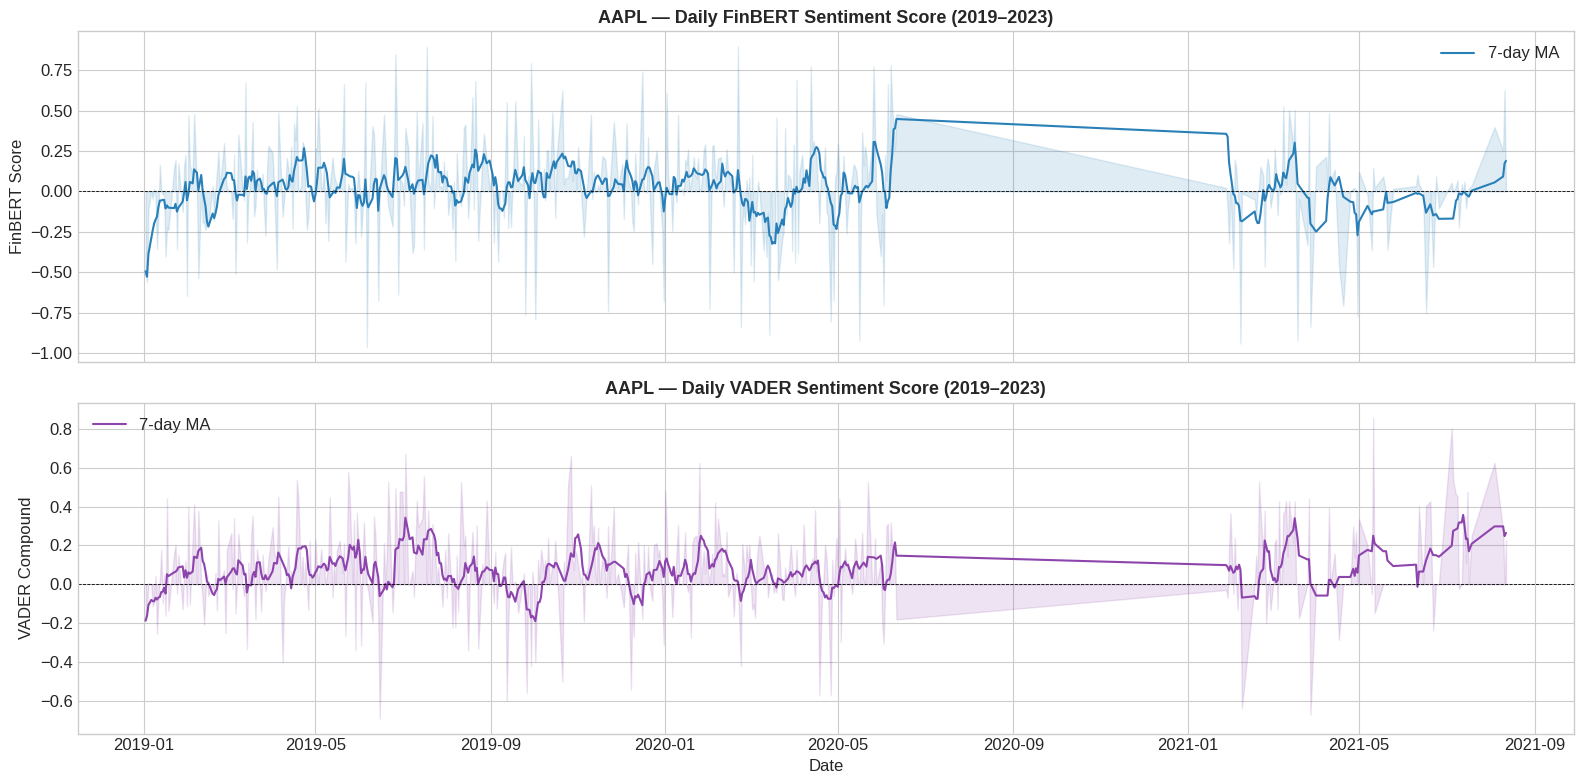

Saved: fig07_sentiment_timeseries.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ticker_plot = 'AAPL'
sent_ticker = daily_sentiment[daily_sentiment['ticker'] == ticker_plot].copy()
sent_ticker = sent_ticker.sort_values('date')

# Rolling 7-day average
sent_ticker['finbert_roll'] = sent_ticker['finbert_score'].rolling(7, min_periods=1).mean()
sent_ticker['vader_roll']   = sent_ticker['vader_compound'].rolling(7, min_periods=1).mean()

# Panel 1: FinBERT
axes[0].fill_between(sent_ticker['date'],
                     sent_ticker['finbert_score'],
                     0, alpha=0.15, color='#2980b9')
axes[0].plot(sent_ticker['date'], sent_ticker['finbert_roll'],
             color='#2980b9', linewidth=1.5, label='7-day MA')
axes[0].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[0].set_ylabel('FinBERT Score')
axes[0].set_title(f'{ticker_plot} — Daily FinBERT Sentiment Score (2019–2023)',
                  fontsize=13, fontweight='bold')
axes[0].legend()

# Panel 2: VADER
axes[1].fill_between(sent_ticker['date'],
                     sent_ticker['vader_compound'],
                     0, alpha=0.15, color='#8e44ad')
axes[1].plot(sent_ticker['date'], sent_ticker['vader_roll'],
             color='#8e44ad', linewidth=1.5, label='7-day MA')
axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[1].set_ylabel('VADER Compound')
axes[1].set_xlabel('Date')
axes[1].set_title(f'{ticker_plot} — Daily VADER Sentiment Score (2019–2023)',
                  fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig07_sentiment_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig07_sentiment_timeseries.png')

## Cell 13 — Sentiment heatmap across all tickers

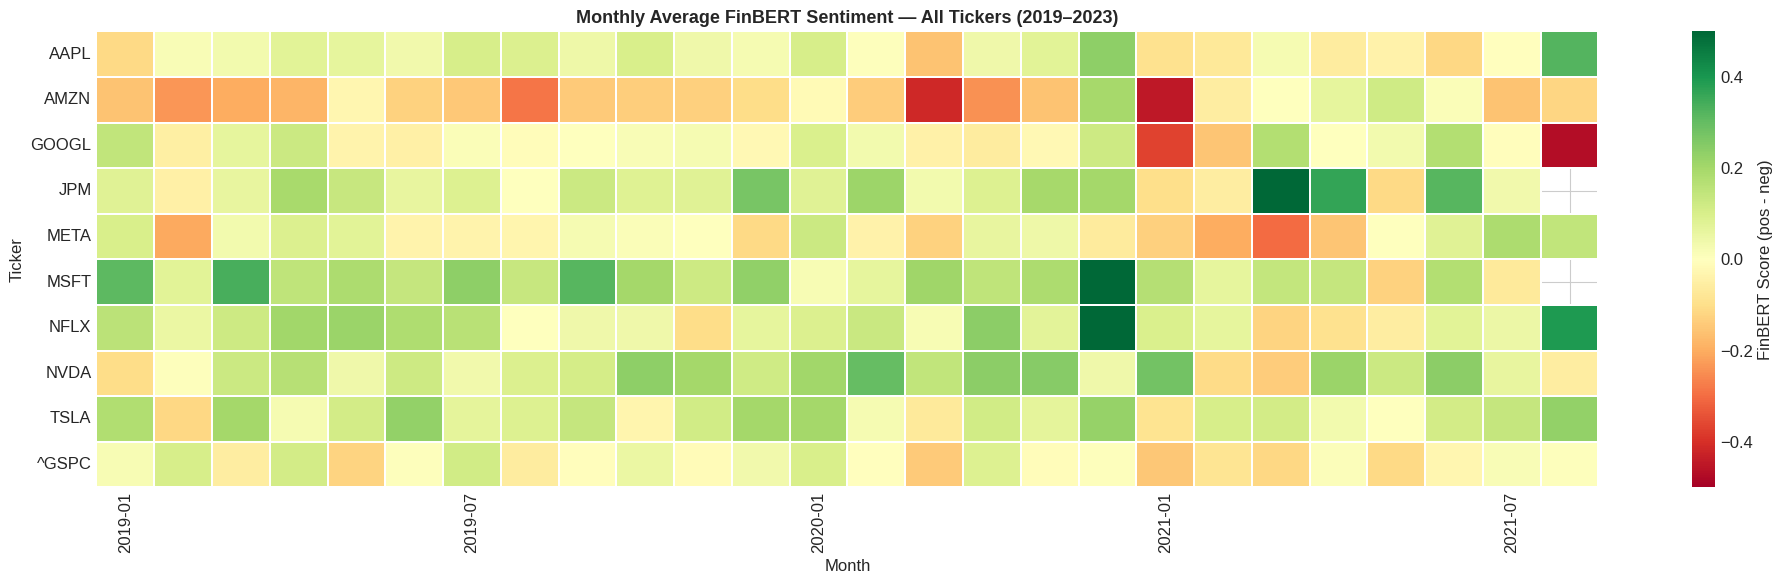

Saved: fig08_sentiment_heatmap.png


In [13]:
# Monthly average FinBERT score per ticker — heatmap
sent_pivot = daily_sentiment.copy()
sent_pivot['year_month'] = pd.to_datetime(sent_pivot['date']).dt.to_period('M').astype(str)

heatmap_data = sent_pivot.pivot_table(
    index='ticker', columns='year_month',
    values='finbert_score', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(
    heatmap_data,
    cmap='RdYlGn', center=0,
    vmin=-0.5, vmax=0.5,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'FinBERT Score (pos - neg)'}
)
ax.set_title('Monthly Average FinBERT Sentiment — All Tickers (2019–2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Ticker')

# Only show every 6th x-axis label to avoid crowding
xticks = ax.get_xticklabels()
for i, lbl in enumerate(xticks):
    if i % 6 != 0:
        lbl.set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig08_sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig08_sentiment_heatmap.png')

## Cell 14 — Save all outputs

In [14]:
# 1. Raw headlines with both sentiment scores
raw_out = f'{OUTPUT_DIR}/headlines_with_sentiment.csv'
news_all.to_csv(raw_out, index=False)
print(f'Saved raw scored headlines : {raw_out}  ({len(news_all):,} rows)')

# 2. Daily aggregated sentiment (primary input to NB3)
daily_out = f'{OUTPUT_DIR}/daily_sentiment.csv'
daily_sentiment.to_csv(daily_out, index=False)
print(f'Saved daily sentiment      : {daily_out}  ({len(daily_sentiment):,} rows)')

# 3. Coverage report
cov_out = f'{OUTPUT_DIR}/sentiment_coverage_report.csv'
cov_df.to_csv(cov_out, index=False)
print(f'Saved coverage report      : {cov_out}')

print('\n=== Notebook 2 Complete ===')
print('Files needed for NB3:')
print('  price_data_clean.csv')
print('  daily_sentiment.csv')
print('Next: Run Notebook 3 — Feature Engineering (CPU is fine)')

Saved raw scored headlines : /kaggle/working/outputs/headlines_with_sentiment.csv  (25,689 rows)
Saved daily sentiment      : /kaggle/working/outputs/daily_sentiment.csv  (4,475 rows)
Saved coverage report      : /kaggle/working/outputs/sentiment_coverage_report.csv

=== Notebook 2 Complete ===
Files needed for NB3:
  price_data_clean.csv
  daily_sentiment.csv
Next: Run Notebook 3 — Feature Engineering (CPU is fine)


---
## Summary
- **FinBERT** (ProsusAI/finbert): domain-specific transformer — outputs positive/negative/neutral probabilities
- **VADER**: lexicon-based — outputs compound score (−1 to +1)
- Both scored on the **same headline corpus** for direct comparison in Chapter 4
- Daily aggregated features: mean score, pos/neg ratio, sentiment momentum
- **Figures saved**: fig06–fig08
- **Key output for NB3**: `daily_sentiment.csv`